In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

import format_chronic_stim
import format_waveform_data
import waveform_analysis

import scipy.io
import os

In [2]:
''' set paths '''
# set parent directory
root_dir = "Z:/Isabel/data/hpc_implants/"

# session params
bird_id = "LIM63"
session_id = "240610"
ephys_id = "LIM63_240610_131820"
show_plots = False

# data directories
session_dir = f"{root_dir}{bird_id}/{bird_id}_{session_id}/{ephys_id}/"
ks_dir = "kilosort4_hash_blanked/"
ephys_dir = "raw_ephys_output/"

# set save folder
save_dir = f"../figures/basic_neural_analysis/{bird_id}/"
save_folder = f"{save_dir}{bird_id}_{session_id}/"
if os.path.isdir(save_folder):
    print('save folder exists')
else:
    if os.path.isdir(save_dir):
        os.mkdir(save_folder)
    else:
        os.mkdir(save_dir)
        os.mkdir(save_folder)

save folder exists


In [3]:
''' load and format the waveform struct '''
waveform_struct = format_waveform_data.load_wf_data(session_dir, ks_dir=ks_dir)
mean_waveforms, max_ch, max_idx = format_waveform_data.sort_wf_by_channel(session_dir, waveform_struct, data_dir=ephys_dir)
n_cells = mean_waveforms.shape[0]

Z:/Isabel/data/hpc_implants/LIM63/LIM63_240610/LIM63_240610_131820/kilosort4_hash_blanked/waveformStruct.mat
dict_keys(['mxWF', 'max_site', 'pcWF', 'meanRate', 'waveFormsMean', 'spkDur', 'spkOffset', 'goodIDs', 'goodLabels', 'medISI', 'contam', 'nSpikes'])
Z:/Isabel/data/hpc_implants/LIM63/LIM63_240610/LIM63_240610_131820/raw_ephys_output/intan_info.mat


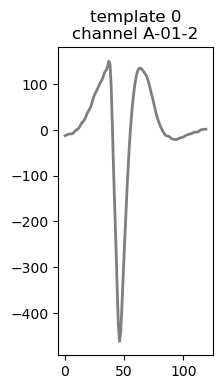

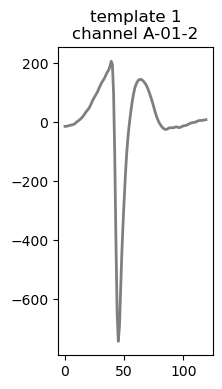

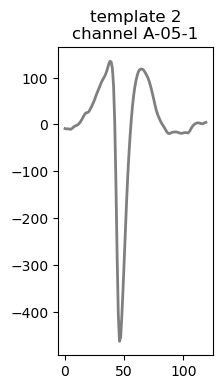

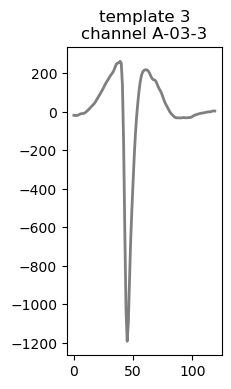

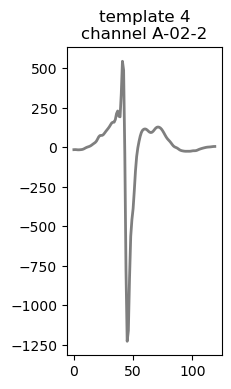

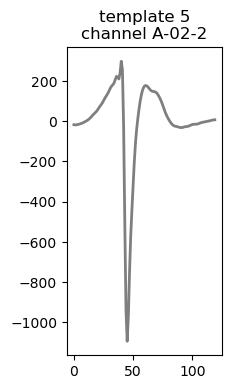

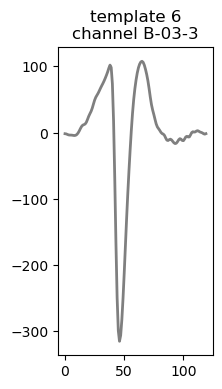

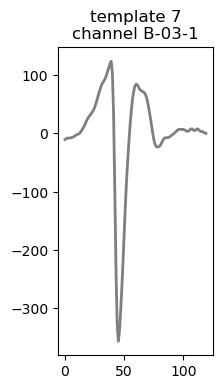

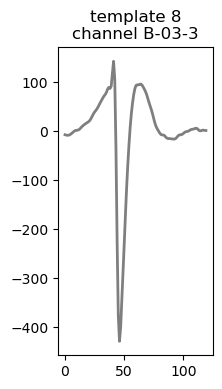

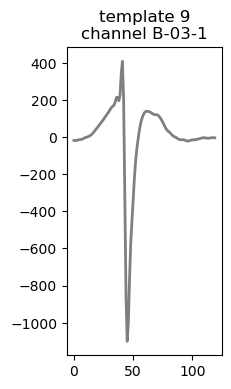

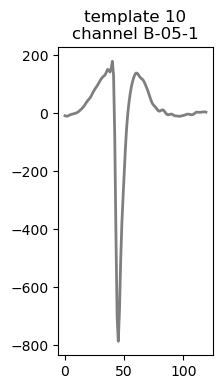

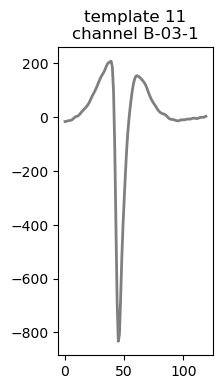

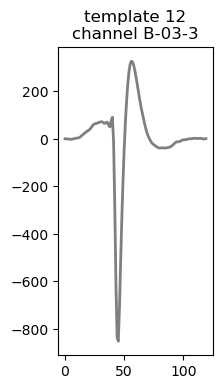

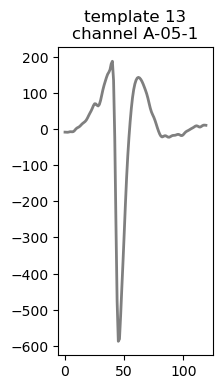

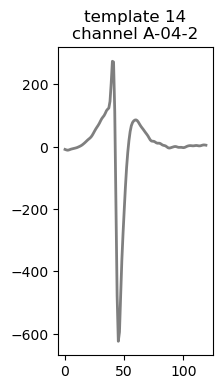

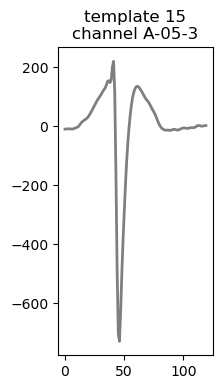

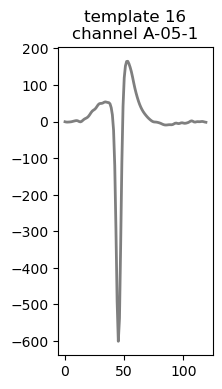

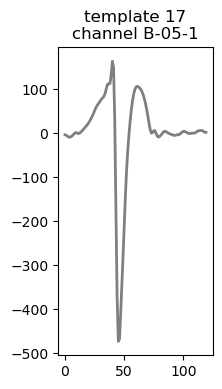

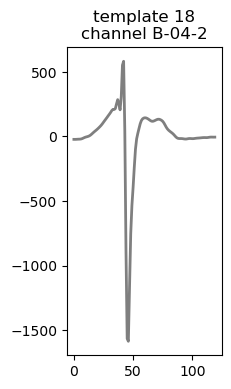

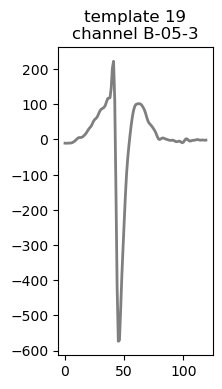

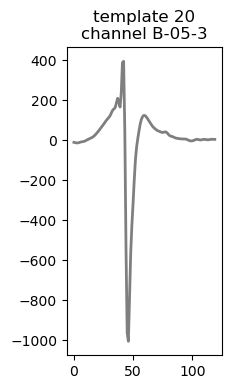

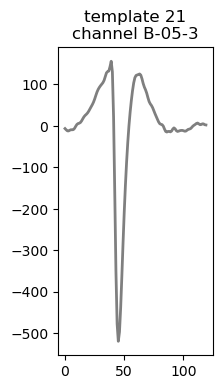

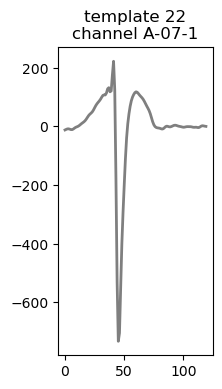

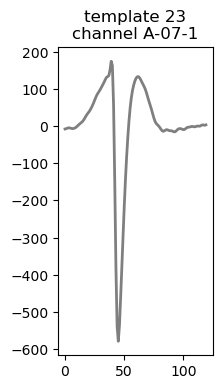

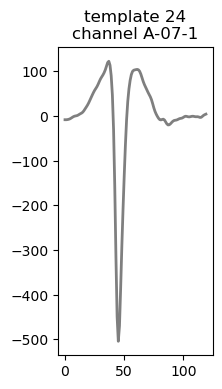

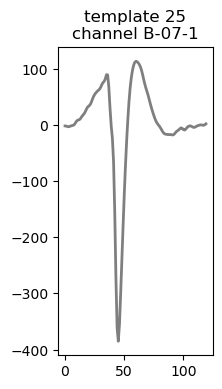

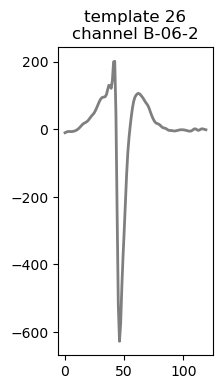

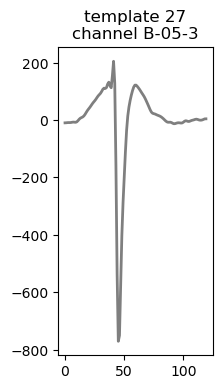

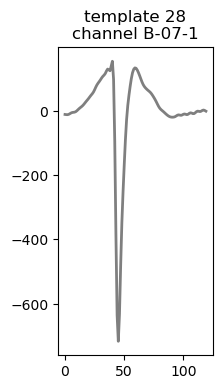

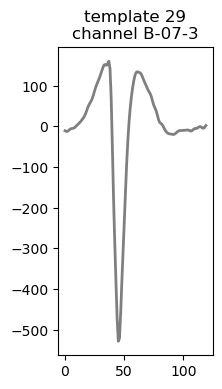

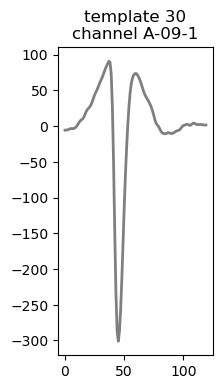

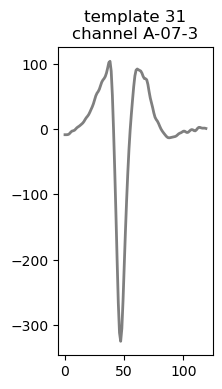

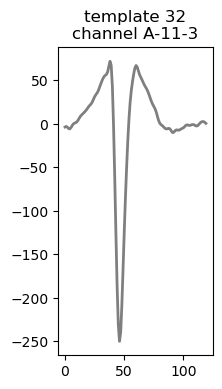

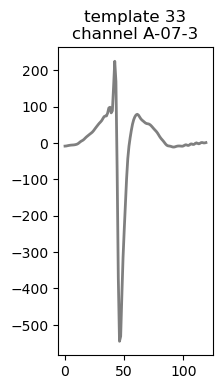

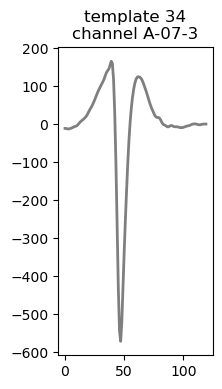

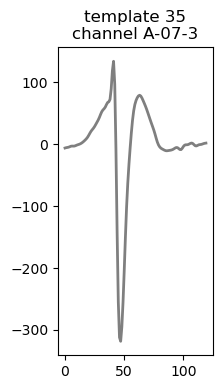

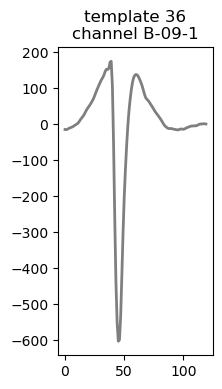

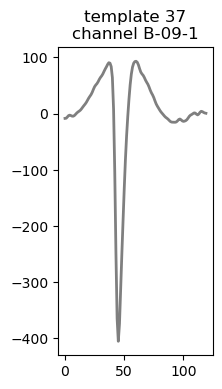

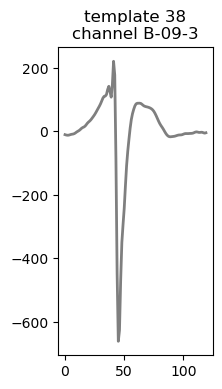

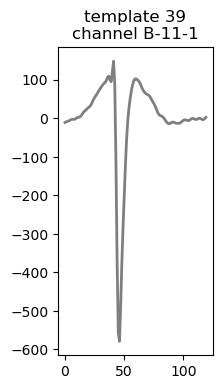

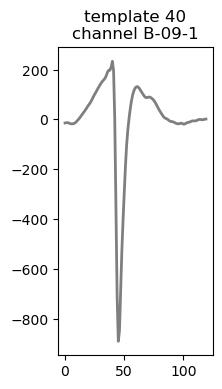

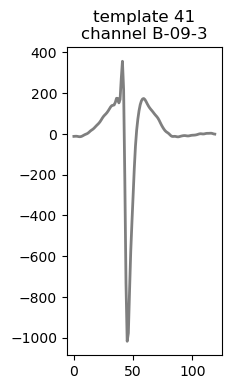

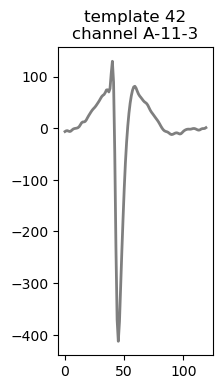

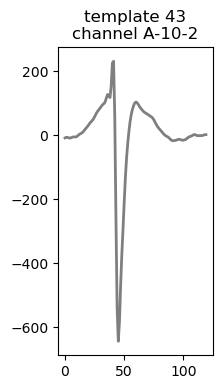

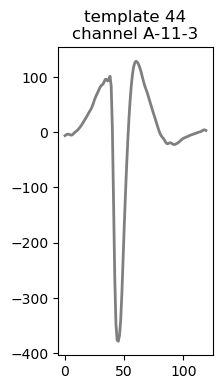

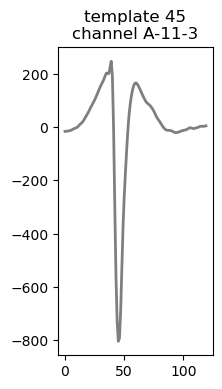

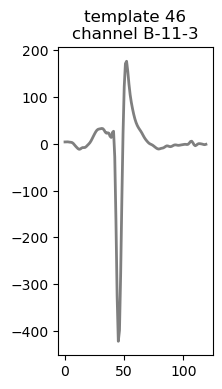

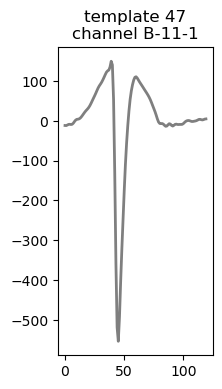

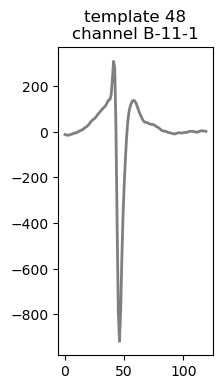

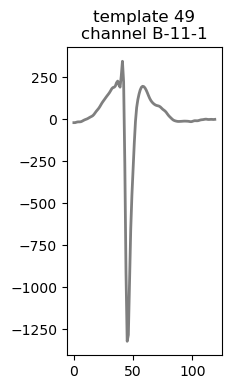

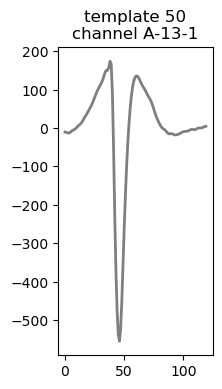

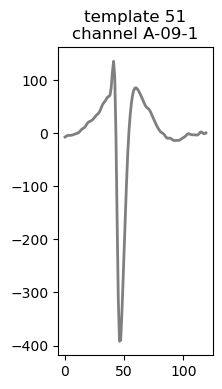

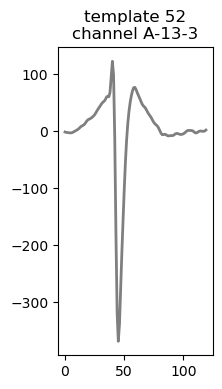

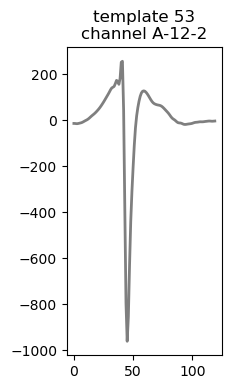

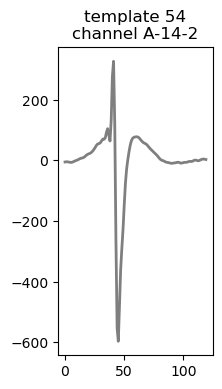

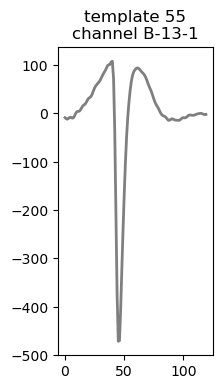

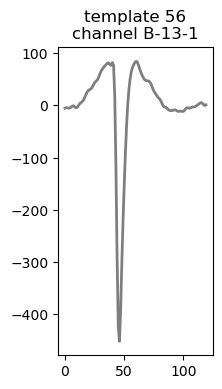

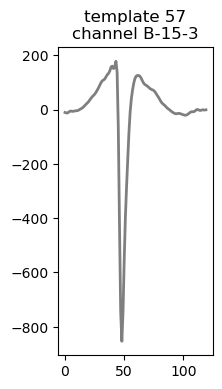

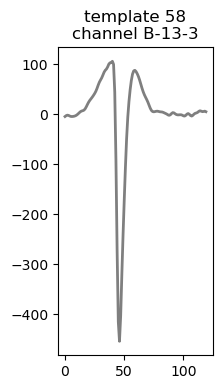

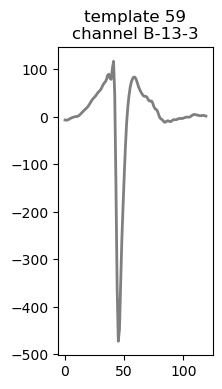

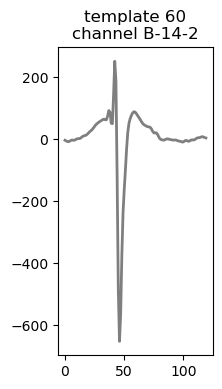

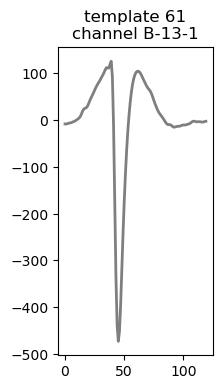

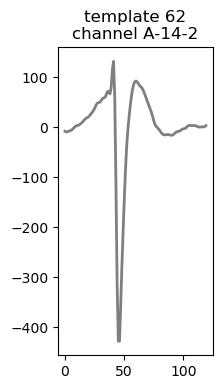

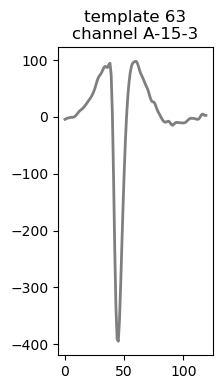

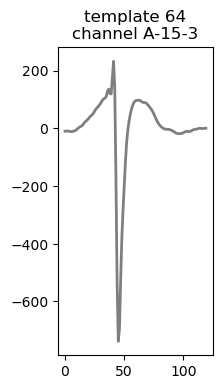

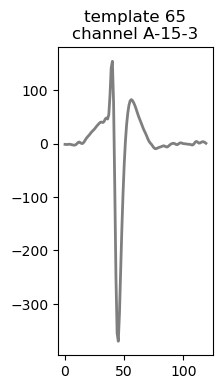

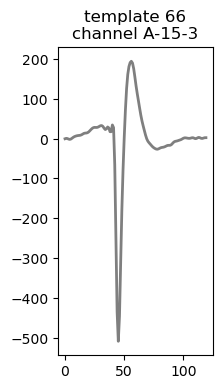

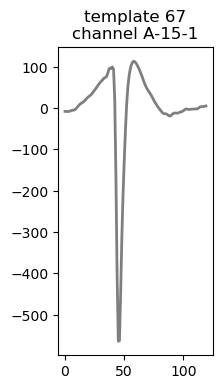

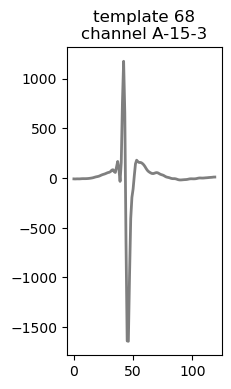

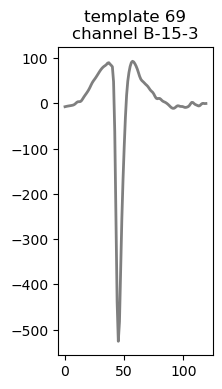

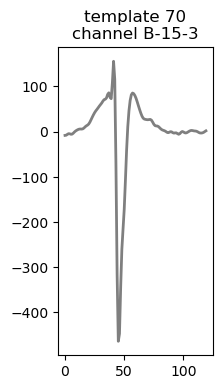

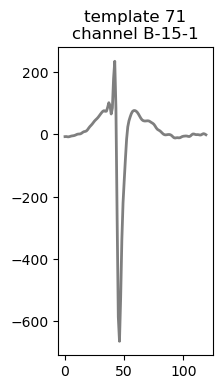

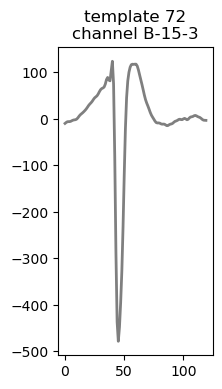

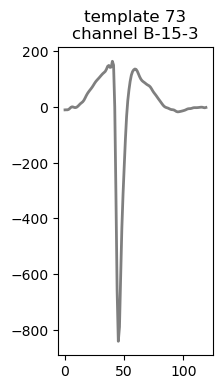

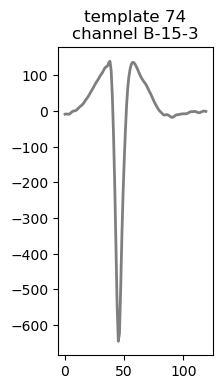

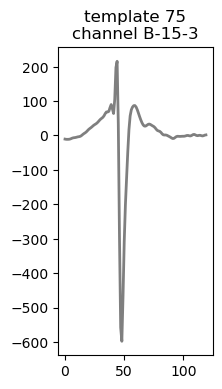

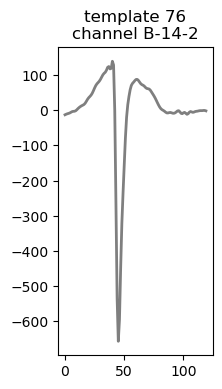

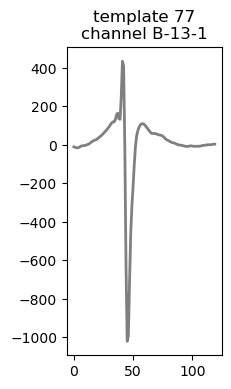

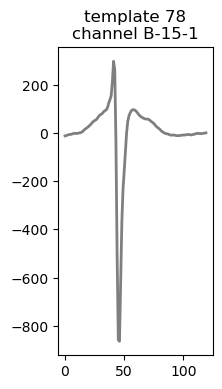

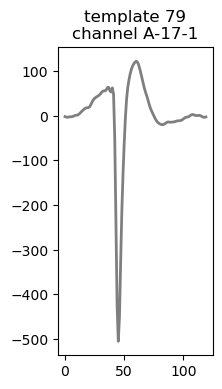

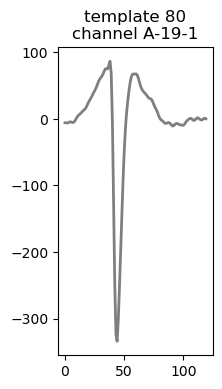

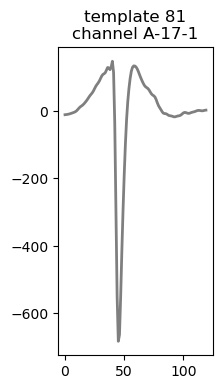

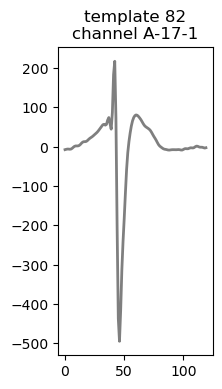

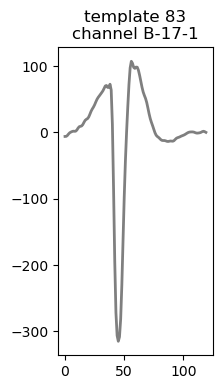

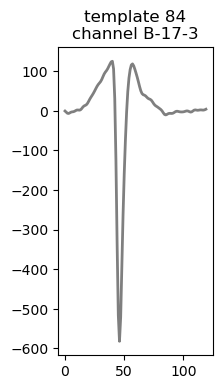

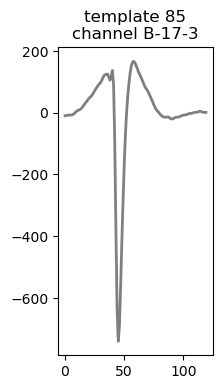

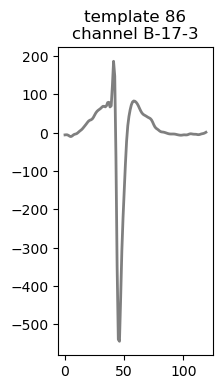

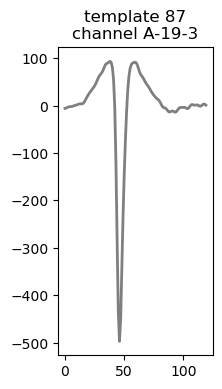

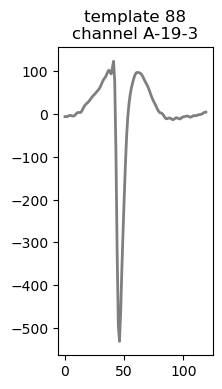

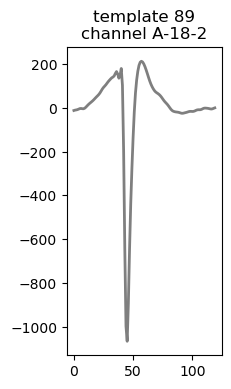

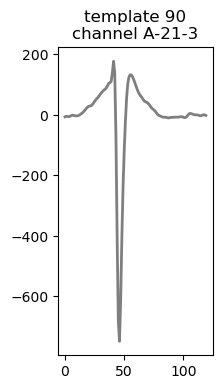

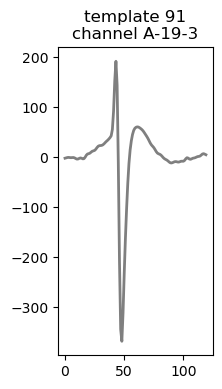

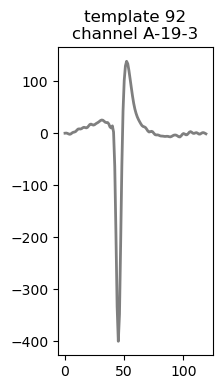

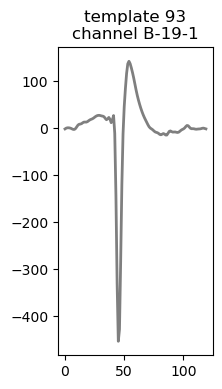

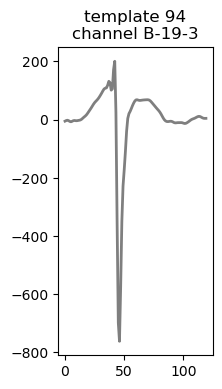

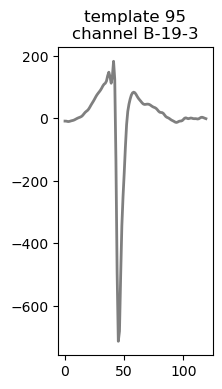

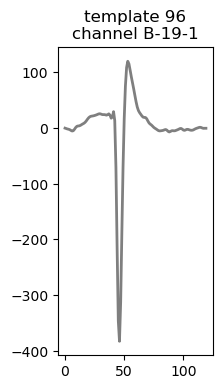

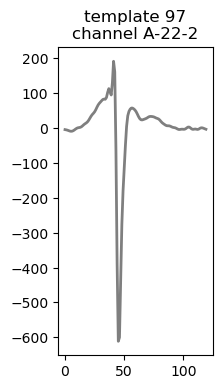

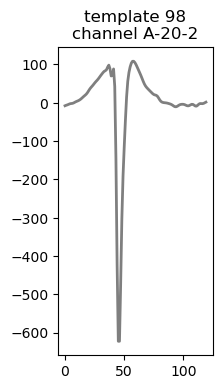

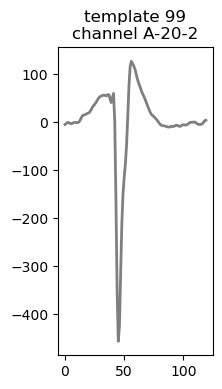

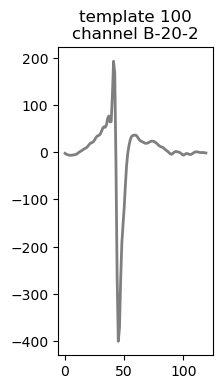

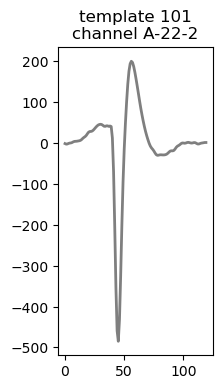

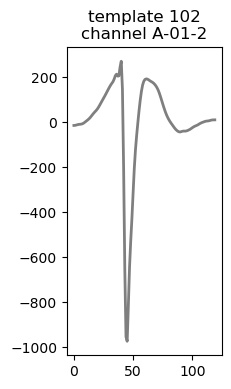

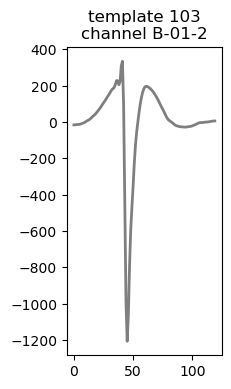

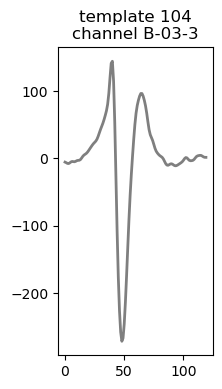

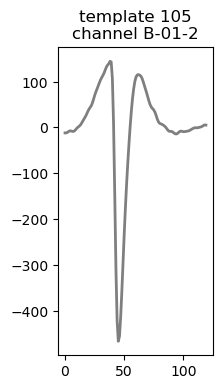

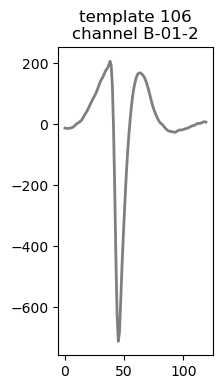

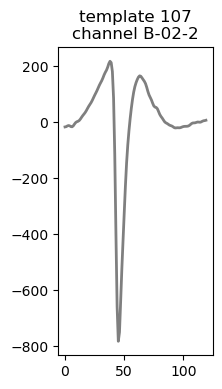

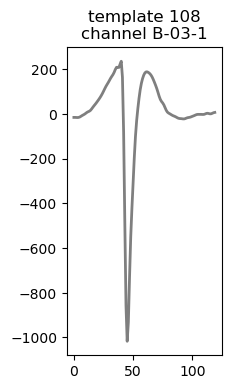

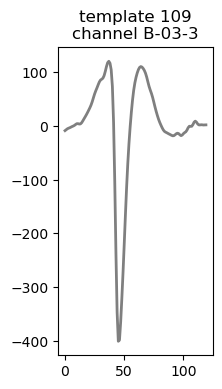

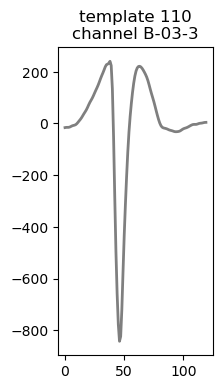

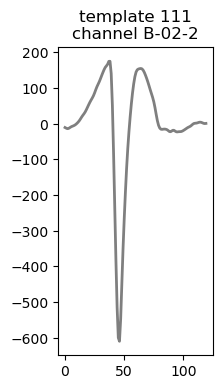

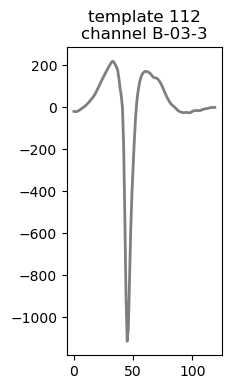

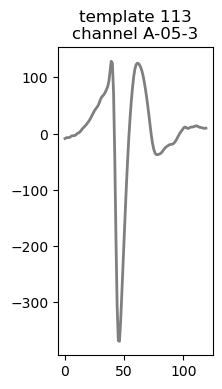

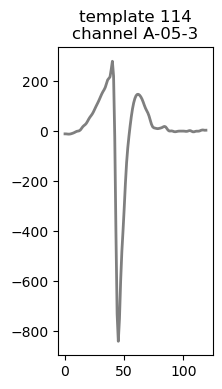

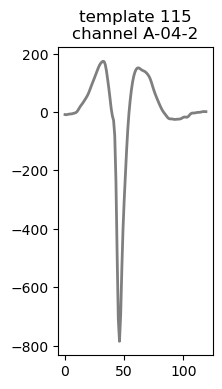

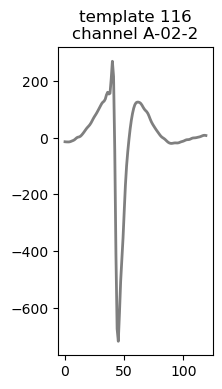

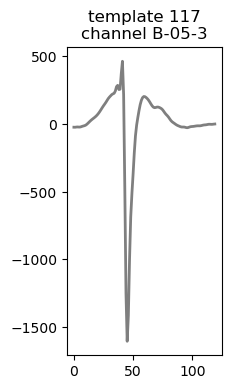

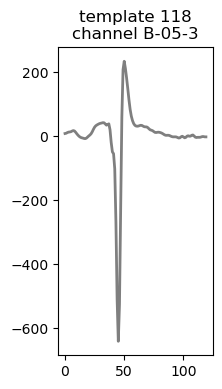

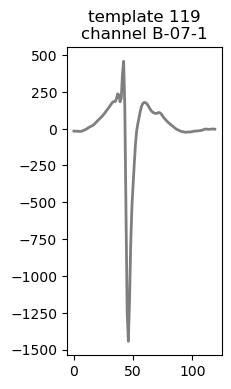

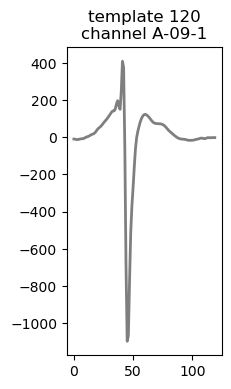

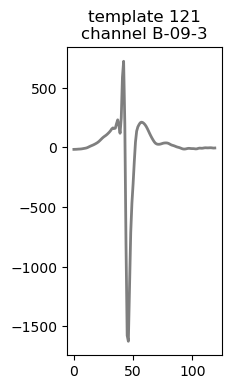

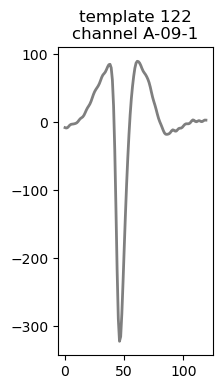

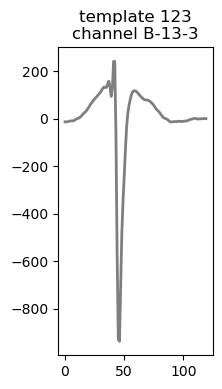

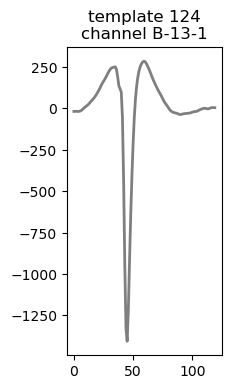

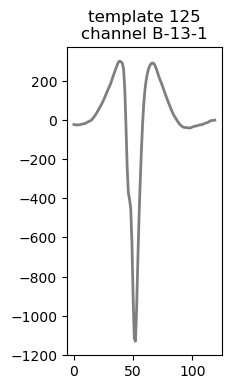

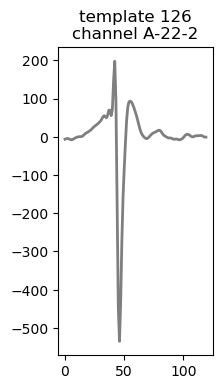

In [4]:
for i in range(n_cells):  
    wf_temp = mean_waveforms[i, max_idx[i]]

    f, ax = plt.subplots(1, 1, figsize=(2, 4))
    ax.plot(wf_temp.T, 'k', lw=2, alpha=0.5)
    plt.title(f'template {i}\nchannel {max_ch[i]}')
    plt.show()

In [5]:
'''
Cluster excitatory vs. inhibitory cells
---------------------------------------
From Payne et al. 2021 Methods

- Spike width: time (ms) from the trough of the avg waveform to the subsequent peak
- Peak amplitude asymmetry: relative height of the two positive peaks flanking the trough
    --> (b-a)/(b+a) where a is the first peak, b is the second
    --> −1 if + 1st peak, - 2nd; 0 when 1st = 2nd; +1 when -1st, + 2nd
- Firing rate (Hz)

Then use k-means clustering on waveforms in this 3D space
'''
# get the waveform properties
all_fr = waveform_struct['meanRate']
all_width = np.zeros(n_cells)
all_assym = np.zeros(n_cells)
for wf_idx in range(n_cells):
    best_ch = max_idx[wf_idx]
    all_width[wf_idx] = waveform_analysis.calc_spike_width(mean_waveforms[wf_idx, best_ch])
    all_assym[wf_idx] = waveform_analysis.calc_amp_assym(mean_waveforms[wf_idx, best_ch])    

In [30]:
# for log scaling...
import matplotlib.ticker as mticker
def log_tick_formatter(val, pos=None):
    return f"$10^{{{val:g}}}$"

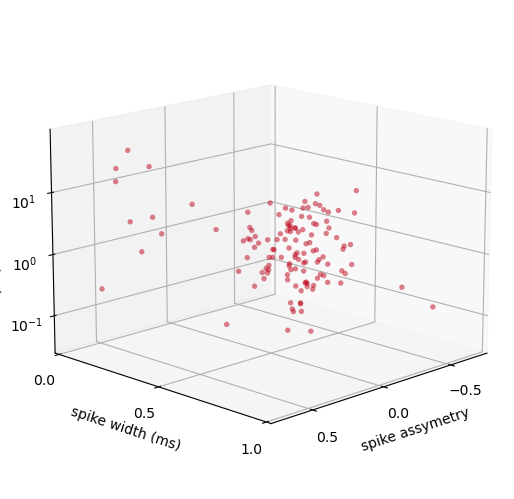

In [40]:
''' plot the waveform properties '''
fig = plt.figure(figsize=(8, 4))
ax = plt.axes([0, 0, .6, 1.2], projection='3d')

ax.scatter(all_assym, all_width, np.log10(all_fr),
           c='xkcd:scarlet', alpha=0.5, lw=0, s=15)

# labels
ax.set_xlabel('spike assymetry')
ax.set_ylabel('spike width (ms)')
ax.set_zlabel('firing rate (Hz)')

# log scale the z-axis
ax.zaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.zaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# limits
ax.set_xlim([-0.75, 0.75])
ax.set_xticks([-0.5, 0, 0.5])
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])

ax.view_init(azim=45, elev=15)

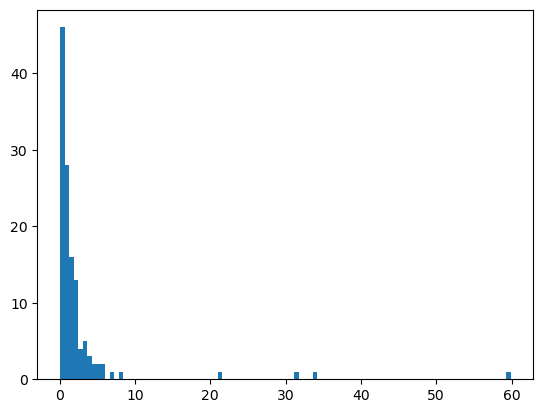

In [48]:
f, ax = plt.subplots(1, 1)
ax.hist(all_fr, bins=100)
plt.show()

In [ ]:
'''
now...do kmeans clustering on those parameters
'''